In [19]:
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt

1. Загрузите данные из файла abalone.csv. Это датасет, в котором требуется предсказать возраст ракушки (число колец) по физическим
измерениям.

In [2]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML_intro/12/abalone.csv")
print(data)

     Sex  Length  Diameter  Height  WholeWeight  ShuckedWeight  VisceraWeight  \
0      M   0.455     0.365   0.095       0.5140         0.2245         0.1010   
1      M   0.350     0.265   0.090       0.2255         0.0995         0.0485   
2      F   0.530     0.420   0.135       0.6770         0.2565         0.1415   
3      M   0.440     0.365   0.125       0.5160         0.2155         0.1140   
4      I   0.330     0.255   0.080       0.2050         0.0895         0.0395   
...   ..     ...       ...     ...          ...            ...            ...   
4172   F   0.565     0.450   0.165       0.8870         0.3700         0.2390   
4173   M   0.590     0.440   0.135       0.9660         0.4390         0.2145   
4174   M   0.600     0.475   0.205       1.1760         0.5255         0.2875   
4175   F   0.625     0.485   0.150       1.0945         0.5310         0.2610   
4176   M   0.710     0.555   0.195       1.9485         0.9455         0.3765   

      ShellWeight  Rings  


2. Преобразуйте признак Sex в числовой: значение F должно перейти
в -1, I — в 0, M — в 1. Если вы используете Pandas, то подойдет следующий код: data[’Sex’] = data[’Sex’].map(lambda x: 1 if x ==
’M’ else (-1 if x == ’F’ else 0))


In [3]:
data["Sex"] = data["Sex"].map(lambda x: 1 if x == "M" else (-1 if x == "F" else 0))

3. Разделите содержимое файлов на признаки и целевую переменную.
В последнем столбце записана целевая переменная, в остальных —
признаки.


In [4]:
y = data['Rings']
X = data.drop(columns=["Rings"])

4. Обучите случайный лес (sklearn.ensemble.RandomForestRegressor)
с различным числом деревьев: от 1 до 50 (random_state=1). Для
каждого из вариантов оцените качество работы полученного леса
на кросс-валидации по 5 блокам. Используйте параметры
"random_state=1"и "shuffle=True"при создании генератора кроссвалидации sklearn.cross_validation.KFold. В качестве меры качества
воспользуйтесь коэффициентом детерминации (sklearn.metrics.r2_score).


In [25]:
kfold = sk.model_selection.KFold(n_splits=5, shuffle=True, random_state=1)
scores = []

for n in range(1, 51):
    rfr = sk.ensemble.RandomForestRegressor(n_estimators=n, random_state=1)
    score = np.mean(sk.model_selection.cross_val_score(rfr, X, y, cv=kfold, scoring='r2'))
    scores.append(score)

5. Определите, при каком минимальном количестве деревьев случайный лес показывает качество на кросс-валидации выше 0.52. Это
количество и будет ответом на задание.

In [26]:
for i in range(len(scores)):
  if scores[i] > 0.52:
    print(i+1, "- минимальное количество деревьев для кросс-валидации выше 0.52")
    break

21 - минимальное количество деревьев для кросс-валидации выше 0.52


6. Обратите внимание на изменение качества по мере роста числа деревьев. Ухудшается ли оно?


/tmp/ipykernel_18109/3544132083.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


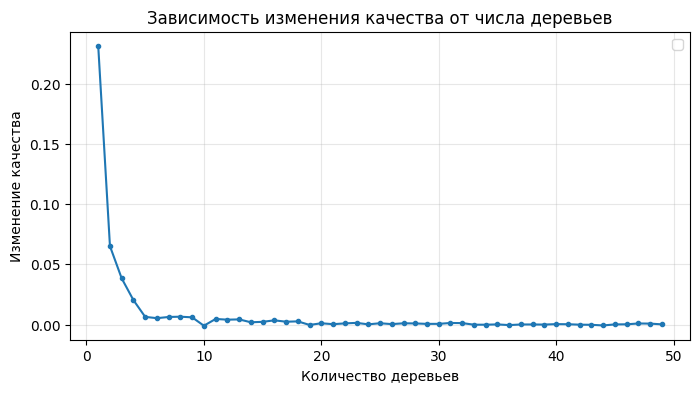

In [28]:
growth = []
for i in range(len(scores)-1):
  growth.append((scores[i+1] - scores[i]).item())

n_range = [i for i in range(1, 50)]

plt.figure(figsize=(8, 4))
plt.plot(n_range, growth, marker='o', markersize=3)
plt.xlabel('Количество деревьев')
plt.ylabel('Изменение качества')
plt.title('Зависимость изменения качества от числа деревьев')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Чем больше становится деревьев, тем менее заметно растет качество.